### Introduction to Autoencoders and Variational Autoencoders (VAEs)

In this tutorial, we will explore the concepts of **Autoencoders (AEs)** and **Variational Autoencoders (VAEs)**, focusing on how they learn latent space representations and reconstruct data. The tutorial is structured to compare the behavior of these models, particularly:

1. **Latent Space Visualization**:
   - We will examine how data is represented in a lower-dimensional latent space.
   - Autoencoders learn latent representations through simple reconstruction, while VAEs impose a probabilistic structure on the latent space.

2. **Reconstruction Quality**:
   - We will observe how the models reconstruct input data from their latent representations.
   - This allows us to understand the impact of the regularization applied in VAEs.

3. **Loss Function Analysis**:
   - Autoencoders minimize the reconstruction loss (e.g., Mean Squared Error, MSE), directly encouraging accurate reconstructions.
   - VAEs use a combination of:
     - **Reconstruction Loss**: Measures the quality of reconstructed data.
     - **KL Divergence**: Regularizes the latent space to match a prior distribution (e.g., a standard Gaussian).

In [ ]:
# Important libraries
import torch
import warnings
import torchvision
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt; plt.rcParams['figure.dpi'] = 100
device = 'cuda' if torch.cuda.is_available() else 'cpu' # Check if GPU is available
warnings.filterwarnings("ignore") 

In [2]:
# Load MNIST dataset, has 60,000 images of hand annotated digits
data = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST('./data',
    transform=torchvision.transforms.ToTensor(),
    download=True),
    batch_size=128,
    shuffle=True
)

In [3]:
# Look at datas shape, should be (batch_size, 1, x pix, y pix)
x, y = next(iter(data))
x.shape, y.shape

(torch.Size([128, 1, 28, 28]), torch.Size([128]))

# Autoencoder

In [ ]:
# Encoder: Compress input to latent space
class Encoder(nn.Module):
    def __init__(self, latent_dims):
        super(Encoder, self).__init__()
        self.linear1 = nn.Linear(784, 512)
        self.linear2 = nn.Linear(512, latent_dims)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)  # Flatten images to (batch_size, 784)
        x = F.relu(self.linear1(x))
        return self.linear2(x)  # Output latent representation

In [7]:
# Test the encoder with a single batch, should output (batch_size, latent_dims)
encoder = Encoder(2)
z = encoder(x)
z.shape

torch.Size([128, 2])

In [8]:
# Decoder: Reconstruct input from latent space
class Decoder(nn.Module):
    def __init__(self, latent_dims):
        super(Decoder, self).__init__()
        self.linear1 = nn.Linear(latent_dims, 512)
        self.linear2 = nn.Linear(512, 784)

    def forward(self, z):
        z = F.relu(self.linear1(z))
        z = torch.sigmoid(self.linear2(z))  # Map to [0, 1] for image pixel values
        return z.reshape((-1, 1, 28, 28))  # Reshape back to (batch_size, 1, 28, 28)

In [9]:
# Test the decoder with a single batch, should output (batch_size, 1, 28, 28)
decoder = Decoder(2)
x_hat = decoder(z)
x_hat.shape

torch.Size([128, 1, 28, 28])

In [10]:
# Autoencoder: Combine Encoder and Decoder
class Autoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(latent_dims)
        self.decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)  # Return reconstructed image

In [11]:
# Test the autoencoder with a single batch, should output (batch_size, 1, 28, 28)
autoencoder = Autoencoder(2)
x_hat = autoencoder(x)
x_hat.shape

torch.Size([128, 1, 28, 28])

In [13]:
# Training loop
def train(autoencoder, data, epochs=20):
    opt = torch.optim.Adam(autoencoder.parameters())
    for epoch in range(epochs):
        for x, _ in data:
            x = x.to(device)
            opt.zero_grad()
            x_hat = autoencoder(x)
            loss = ((x - x_hat) ** 2).sum()  # Reconstruction loss (MSE)
            loss.backward()
            opt.step()
    return autoencoder

# VAE

In [ ]:
# Variational Encoder with reparameterization trick
# Refer to the lecture slides, the forward pass should have an attribute that allows for the KL divergence to be calculated
# Since it only depends on the encoder network
# Also remember to include the reparameterization trick in the forward pass, this means you need self.normal somewhere
class VariationalEncoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalEncoder, self).__init__()
        self.linear1 = nn.Linear(784, 512)
        self.linear_mu = nn.Linear(512, latent_dims)
        self.linear_logvar = nn.Linear(512, latent_dims)
        self.N = torch.distributions.Normal(0, 1) # Normal distribution for reparameterization trick

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.linear1(x))
        mu = self.linear_mu(x)  # Mean of latent distribution
        logvar = self.linear_logvar(x)  # This can be posative or negative, we can use it directly in the loss between two gaussians
        sigma = torch.exp(0.5 * logvar)  # Standard deviation of latent distribution (do the math: logvar = log(sigma^2) => sigma = exp(0.5 * logvar))
        # Reparameterization, sample from N(0, 1) and scale by sigma, then shift by mu to get z, takes the randomness out of the network and allows for backpropagation
        z = mu + sigma * self.N.sample(mu.shape).to(device) # Sample from N(0, 1) and scale and shift, behaves like sampling from N(mu, sigma^2)
        self.kl = 0.5 * (sigma**2 + mu**2 - 1 - logvar).sum()  # KL divergence between N(mu, sigma^2) and N(0, 1)
        return z # Return latent representation sampled from N(mu, sigma^2)

In [ ]:
# Test the VariationalEncoder with a single batch, should output (batch_size, latent_dims) representing the latent space of a two-dimensional gaussian
encoder = VariationalEncoder(2)
z = encoder(x)
z.shape

torch.Size([128, 2])

In [22]:
# Variational Autoencoder (VAE), reuse the Decoder class from the previous example 
class VariationalAutoencoder(nn.Module):
    def __init__(self, latent_dims):
        super(VariationalAutoencoder, self).__init__()
        self.encoder = VariationalEncoder(latent_dims)
        self.decoder = Decoder(latent_dims)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

In [23]:
# Test the VAE with a single batch, should output (batch_size, 1, 28, 28)
vae = VariationalAutoencoder(2)
x_hat = vae(x)
x_hat.shape

torch.Size([128, 1, 28, 28])

In [26]:
# Create a training loop for the VAE
def train_vae(vae, data, epochs=20):
    opt = torch.optim.Adam(vae.parameters())
    for epoch in range(epochs):
        for x, _ in data:
            x = x.to(device)
            opt.zero_grad()
            x_hat = vae(x)
            # Reconstruction loss (MSE) + KL divergence
            loss = ((x - x_hat) ** 2).sum() + vae.encoder.kl 
            loss.backward()
            opt.step()
    return vae

**Train both the Autoencoder and VAE and visualize the latent space and reconstructed images**

In [27]:
# Latent space visualization
def plot_latent(autoencoder, data, num_batches=100):
    for i, (x, y) in enumerate(data):
        # Sample latent space representation
        z = autoencoder.encoder(x.to(device))
        z = z.to('cpu').detach().numpy()
        plt.scatter(z[:, 0], z[:, 1], c=y, cmap='tab10', alpha=0.5, s=1)
        if i > num_batches:
            plt.colorbar()
            break
    plt.show()

In [28]:
# Reconstructed image grid visualization (Run function as is to visualize reconstructed images)
def plot_reconstructed(autoencoder, r0=(-5, 10), r1=(-10, 5), n=12): # Default range and grid size
    w = 28 # Image width
    img = np.zeros((n * w, n * w)) # Blank image
    for i, y in enumerate(np.linspace(*r1, n)): # Iterate over latent space
        for j, x in enumerate(np.linspace(*r0, n)): # Iterate over latent space
            z = torch.Tensor([[x, y]]).to(device) # Single latent space representation
            x_hat = autoencoder.decoder(z) # Reconstruct image
            x_hat = x_hat.reshape(28, 28).to('cpu').detach().numpy() # Reshape and move to CPU
            img[(n-1-i)*w:(n-1-i+1)*w, j*w:(j+1)*w] = x_hat # Add image to grid
    plt.axis('off')
    plt.imshow(img, extent=[*r0, *r1], cmap='binary')
    plt.show()

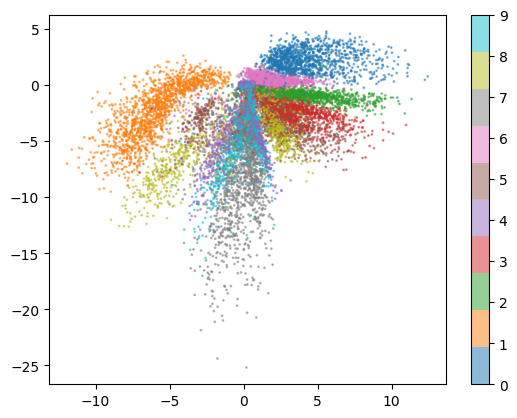

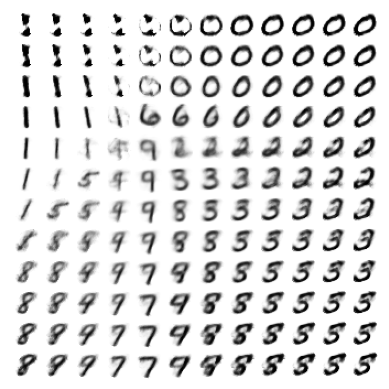

In [29]:
# Autoencoder example
latent_dims = 2
autoencoder = Autoencoder(latent_dims).to(device)
autoencoder = train(autoencoder, data)
plot_latent(autoencoder, data)
plot_reconstructed(autoencoder)

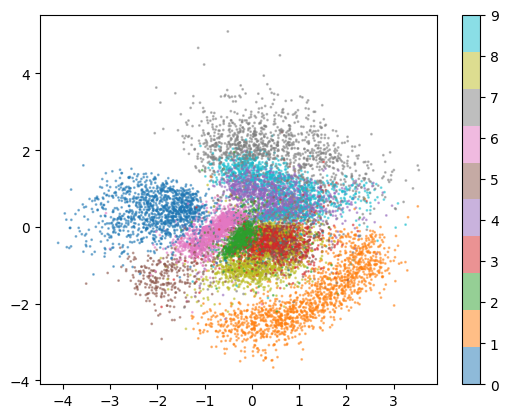

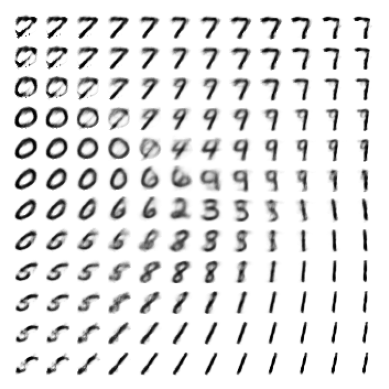

In [30]:
# VAE example
vae = VariationalAutoencoder(latent_dims).to(device)
vae = train_vae(vae, data)
plot_latent(vae, data)
plot_reconstructed(vae, r0=(-3, 3), r1=(-3, 3))

In [ ]:
# Modify the VAE training loop and consider the case of no MSE loss and only KL divergence. Plot the latent space and reconstructed images for both cases.

In [ ]:
# 1) Only KL divergence
def train_vae(vae, data, epochs=20, kl_weight=1):
    opt = torch.optim.Adam(vae.parameters())
    for epoch in range(epochs):
        for x, _ in data:
            x = x.to(device)
            opt.zero_grad()
            x_hat = vae(x)
            # Reconstruction loss (MSE) + KL divergence 
            loss = kl_weight * vae.encoder.kl
            loss.backward()
            opt.step()
    return

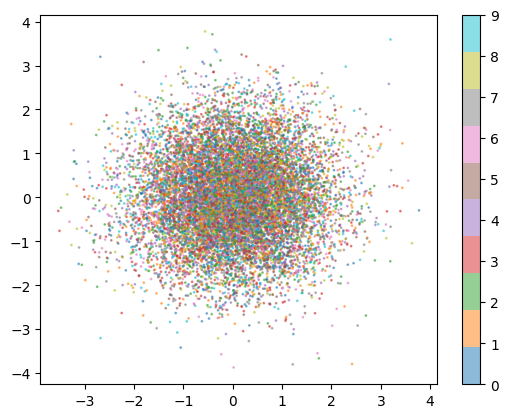

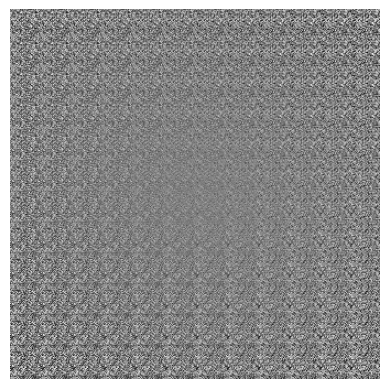

In [32]:
# Plot the latent space and reconstructed images for the VAE with only KL divergence
vae = VariationalAutoencoder(2).to(device)
train_vae(vae, data, kl_weight=1)
plot_latent(vae, data)
plot_reconstructed(vae, r0=(-3, 3), r1=(-3, 3))

In [ ]:
# Can you explain your observations?

# When only training on the KL divergence, the model tries to fit the prior distribution of the latent space, i.e., unit Gaussian.
# This results in a latent space that is more evenly distributed and terrible reconstructions, as the model does not care about the input data.

In [33]:
# 2) Only MSE loss
def train_vae(vae, data, epochs=20, kl_weight=1):
    opt = torch.optim.Adam(vae.parameters())
    for epoch in range(epochs):
        for x, _ in data:
            x = x.to(device)
            opt.zero_grad()
            x_hat = vae(x)
            # Reconstruction loss (MSE) + KL divergence 
            loss = ((x - x_hat) ** 2).sum()
            loss.backward()
            opt.step()
    return

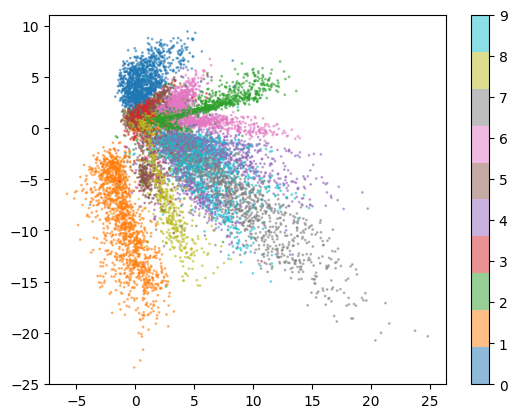

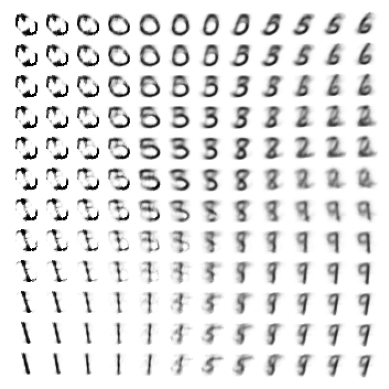

In [34]:
# Plot the latent space and reconstructed images for the VAE with only MSE loss
vae = VariationalAutoencoder(2).to(device)
train_vae(vae, data, kl_weight=0)
plot_latent(vae, data)
plot_reconstructed(vae, r0=(-3, 3), r1=(-3, 3))

In [ ]:
# Can you explain your observations?

# When only training on the MSE loss, the model tries to fit the input data as closely as possible, without considering the prior.
# The model becomes an autoencoder, and the latent space is not structured in any meaningful way, resulting in poor generalization.